**Retail Analytics & AI-Powered Sales
Forecasting System**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Retail_Sales_Data_Unlox (1).csv")

# View first 5 rows
print(df.head())

# Check columns
print("\nColumns:")
print(df.columns)

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Basic info
print("\nInfo:")
print(df.info())

         Date Store_ID Store_Location Product_ID Product_Category  \
0  2023-04-13  STR_104        Chennai    PRD_072           Sports   
1  2024-10-25  STR_103          Delhi    PRD_492           Sports   
2  2023-02-28  STR_107        Kolkata    PRD_958        Groceries   
3  2023-06-16  STR_102      Bangalore    PRD_014  Home Appliances   
4  2024-05-23  STR_108      Ahmedabad    PRD_932          Fashion   

  Product_Subcategory      Brand  Unit_Price  Units_Sold  Total_Sales  \
0           Athletics     Reebok    29973.06          39   1168949.34   
1             Outdoor      Yonex    46933.78           2     93867.56   
2           Household     Nestle    39280.28          44   1728332.32   
3             Kitchen  Whirlpool    40439.03           9    363951.27   
4      Women Clothing       Puma     9193.58           4     36774.32   

   Discount_Percentage       Revenue Customer_Type Payment_Mode  \
0                    5  1.110502e+06     Returning   Debit Card   
1           

**The dataset contains transactional retail data with multiple features such as store details, product categories, pricing, and sales metrics. No missing values are observed, ensuring data quality for further analysis.**

**Data Cleaning + Feature Engineering**

In [ ]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create new time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

print(df.head())

        Date Store_ID Store_Location Product_ID Product_Category  \
0 2023-04-13  STR_104        Chennai    PRD_072           Sports   
1 2024-10-25  STR_103          Delhi    PRD_492           Sports   
2 2023-02-28  STR_107        Kolkata    PRD_958        Groceries   
3 2023-06-16  STR_102      Bangalore    PRD_014  Home Appliances   
4 2024-05-23  STR_108      Ahmedabad    PRD_932          Fashion   

  Product_Subcategory      Brand  Unit_Price  Units_Sold  Total_Sales  ...  \
0           Athletics     Reebok    29973.06          39   1168949.34  ...   
1             Outdoor      Yonex    46933.78           2     93867.56  ...   
2           Household     Nestle    39280.28          44   1728332.32  ...   
3             Kitchen  Whirlpool    40439.03           9    363951.27  ...   
4      Women Clothing       Puma     9193.58           4     36774.32  ...   

   Payment_Mode  Promotion_Applied Stock_On_Hand Store_Rating Region  \
0    Debit Card                Yes           422  

#####I extracted temporal features to capture seasonality and trends in sales

**Weekend Flag**

In [ ]:
df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday']).astype(int)

**First Plot:** Sales Over Time

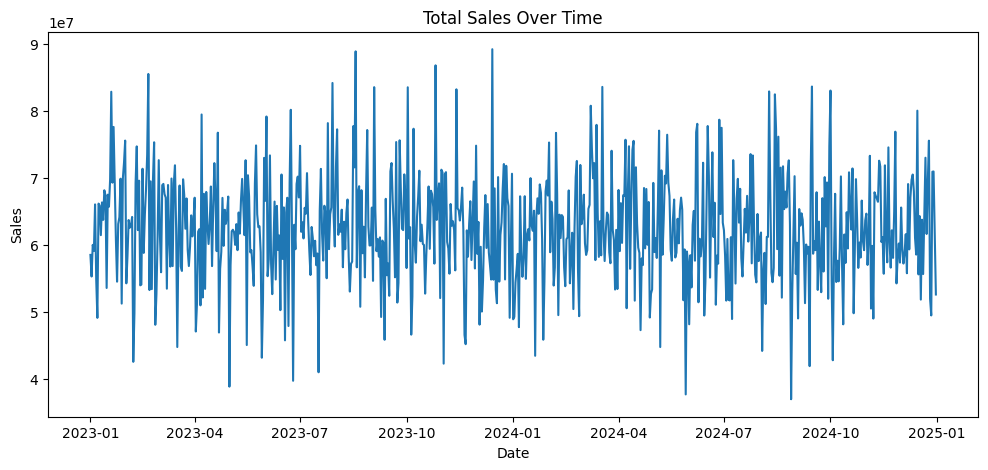

In [ ]:
import matplotlib.pyplot as plt

# Group by date
sales_trend = df.groupby('Date')['Total_Sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_trend)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

**Second Plot**: Monthly Sales

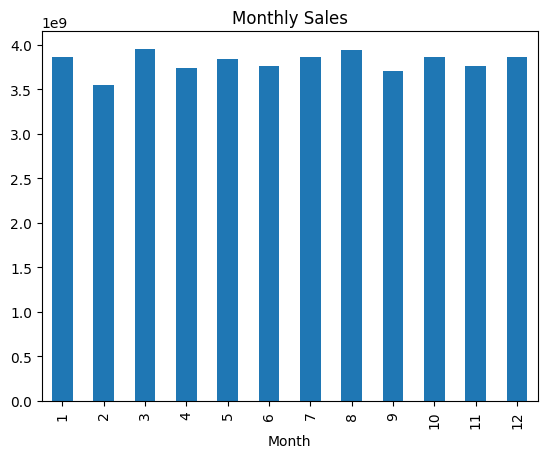

In [ ]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

monthly_sales.plot(kind='bar', title="Monthly Sales")
plt.show()

**Third Plot:** Category-wise Sales

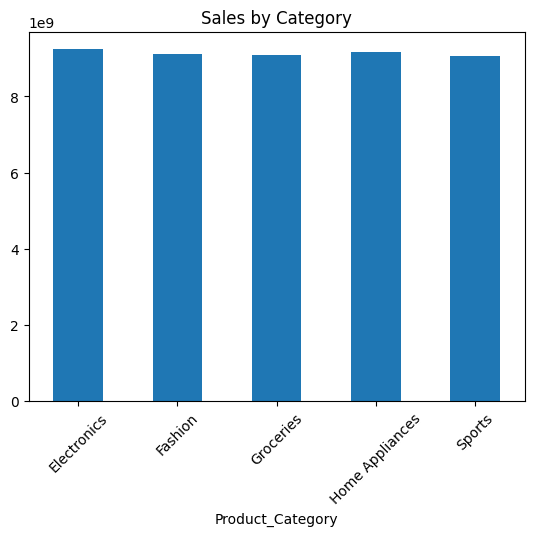

In [ ]:
category_sales = df.groupby('Product_Category')['Total_Sales'].sum()

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xticks(rotation=45)
plt.show()

Prepare Data for Model

In [ ]:
from sklearn.model_selection import train_test_split

# Features (IMPORTANT: select only useful ones)
features = ['Unit_Price', 'Units_Sold', 'Discount_Percentage',
            'Stock_On_Hand', 'Store_Rating',
            'Year', 'Month', 'Day', 'Is_Weekend']

X = df[features]
y = df['Total_Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

Prediction + Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 655.7916509178038
RMSE: 1038.570942169426


**Store Segmentation**

In [ ]:
from sklearn.cluster import KMeans

# Create store-level dataset
store_data = df.groupby('Store_ID').agg({
    'Total_Sales': 'sum',
    'Units_Sold': 'sum'
}).reset_index()

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
store_data['Cluster'] = kmeans.fit_predict(store_data[['Total_Sales', 'Units_Sold']])

print(store_data.head())

  Store_ID   Total_Sales  Units_Sold  Cluster
0  STR_101  2.447965e+09     96754.0        0
1  STR_102  2.415826e+09     95601.0        2
2  STR_103  2.455956e+09     98204.0        0
3  STR_104  2.467243e+09     96934.0        0
4  STR_105  2.356311e+09     93610.0        1


**Visualize Clusters**

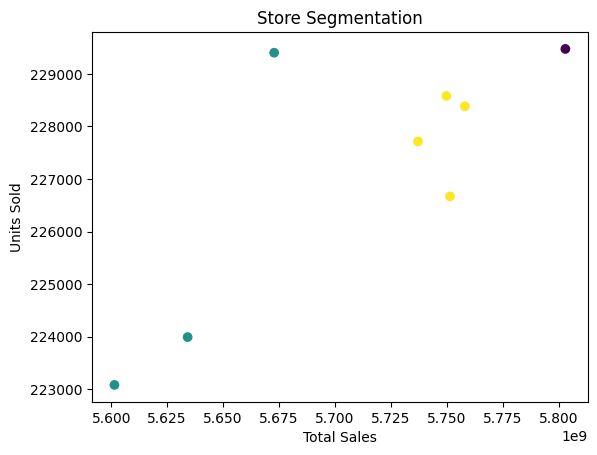

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(store_data['Total_Sales'], store_data['Units_Sold'], c=store_data['Cluster'])
plt.xlabel("Total Sales")
plt.ylabel("Units Sold")
plt.title("Store Segmentation")
plt.show()

**Business Recommended Engine**

In [ ]:
def generate_recommendations():
    recommendations = []

    # High sales months
    recommendations.append("Increase inventory and marketing during peak months like March and August.")

    # Category insight
    recommendations.append("Maintain balanced investment across categories as all contribute significantly.")

    # Store segmentation
    recommendations.append("Focus on improving low-performing stores through targeted promotions and offers.")

    # Pricing & discount
    recommendations.append("Optimize discount strategies to maximize revenue without heavy margin loss.")

    # Weekend strategy
    recommendations.append("Leverage weekend sales by running special campaigns and promotions.")

    return recommendations


recs = generate_recommendations()

for i, rec in enumerate(recs, 1):
    print(f"{i}. {rec}")

1. Increase inventory and marketing during peak months like March and August.
2. Maintain balanced investment across categories as all contribute significantly.
3. Focus on improving low-performing stores through targeted promotions and offers.
4. Optimize discount strategies to maximize revenue without heavy margin loss.
5. Leverage weekend sales by running special campaigns and promotions.


**Time-Series Forcast**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Aggregate daily sales
ts_data = df.groupby('Date')['Total_Sales'].sum()

# Fit ARIMA model
model_arima = ARIMA(ts_data, order=(1,1,1))
model_arima_fit = model_arima.fit()

# Forecast next 30 days
forecast = model_arima_fit.forecast(steps=30)

print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2025-01-01    2.643874e+07
2025-01-02    2.639136e+07
2025-01-03    2.638906e+07
2025-01-04    2.638895e+07
2025-01-05    2.638894e+07
2025-01-06    2.638894e+07
2025-01-07    2.638894e+07
2025-01-08    2.638894e+07
2025-01-09    2.638894e+07
2025-01-10    2.638894e+07
2025-01-11    2.638894e+07
2025-01-12    2.638894e+07
2025-01-13    2.638894e+07
2025-01-14    2.638894e+07
2025-01-15    2.638894e+07
2025-01-16    2.638894e+07
2025-01-17    2.638894e+07
2025-01-18    2.638894e+07
2025-01-19    2.638894e+07
2025-01-20    2.638894e+07
2025-01-21    2.638894e+07
2025-01-22    2.638894e+07
2025-01-23    2.638894e+07
2025-01-24    2.638894e+07
2025-01-25    2.638894e+07
2025-01-26    2.638894e+07
2025-01-27    2.638894e+07
2025-01-28    2.638894e+07
2025-01-29    2.638894e+07
2025-01-30    2.638894e+07
Freq: D, Name: predicted_mean, dtype: float64


Plot forecast

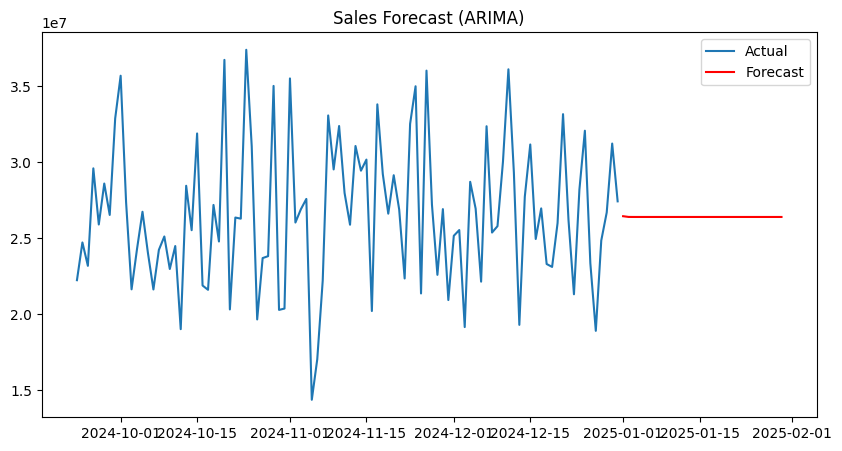

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ts_data[-100:], label="Actual")
plt.plot(forecast, label="Forecast", color='red')
plt.legend()
plt.title("Sales Forecast (ARIMA)")
plt.show()

The stabilization of forecast values suggests that the retail system has reached a steady-state demand pattern.

In [ ]:
import pandas as pd

df = pd.read_csv("Retail_Sales_Data_Unlox (1).csv")
df['Date'] = pd.to_datetime(df['Date'])

# Recreate features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday']).astype(int)

In [ ]:
features = ['Unit_Price', 'Units_Sold', 'Discount_Percentage',
            'Stock_On_Hand', 'Store_Rating',
            'Year', 'Month', 'Day', 'Is_Weekend']

X = df[features]
y = df['Total_Sales']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

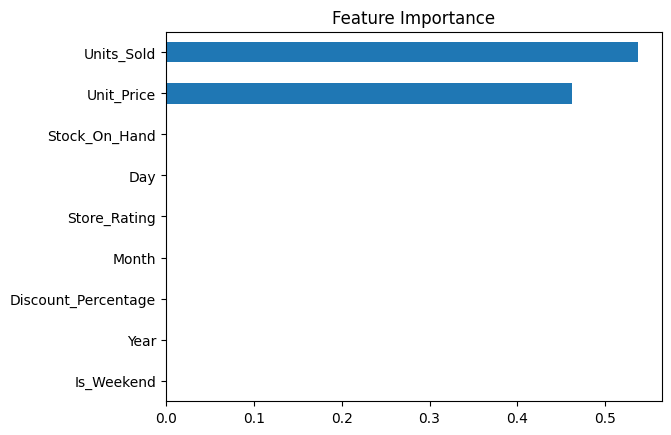

In [ ]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', title="Feature Importance")
plt.show()